# HW14 – Эмбеддинги, FAISS, оценка retrieval и mini-RAG

**Цель:** построить учебный retrieval-конвейер на базе знаний о Python и машинном обучении:
чанкинг → эмбеддинги → индекс FAISS → оценка retrieval → обновление базы → mini-RAG.

## 1. Импорты, seed и среда

In [1]:
import os
import re
import sys
import json
import random
import subprocess
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
from sklearn.feature_extraction.text import TfidfVectorizer

os.environ["TOKENIZERS_PARALLELISM"] = "false"


def ensure_package(package_name: str, import_name: Optional[str] = None) -> None:
    target = import_name or package_name
    try:
        __import__(target)
    except Exception:
        print(f"Устанавливаем пакет: {package_name}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package_name])


ensure_package("faiss-cpu", "faiss")
ensure_package("sentence-transformers", "sentence_transformers")

import faiss

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("FAISS:", faiss.__version__ if hasattr(faiss, '__version__') else 'OK')

c:\Users\Maxim\Downloads\ai-student-maxim-main (4)\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


NumPy: 2.4.4
Pandas: 3.0.2
FAISS: 1.13.2


In [2]:
SEED = 42


def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)


set_seed(SEED)

try:
    import torch
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
except Exception:
    DEVICE = "cpu"

print("Устройство:", DEVICE)
print("Seed:", SEED)

Устройство: cpu
Seed: 42


## 2. База знаний и первичный анализ

**Предметная область:** основные концепции машинного обучения и обработки данных.  
База содержит 20 коротких тематических документов, охватывающих ключевые понятия ML-pipeline:
от предобработки данных до развёртывания моделей. По этим документам удобно строить retrieval,
так как вопросы можно сформулировать на любом этапе pipeline.

In [3]:
documents: List[Dict[str, str]] = [
    {
        "doc_id": "doc_01",
        "title": "Линейная регрессия",
        "text": (
            "Линейная регрессия — один из простейших методов машинного обучения. "
            "Она моделирует зависимость целевой переменной от признаков как линейную комбинацию весов. "
            "Обучение сводится к минимизации среднеквадратичной ошибки (MSE) между предсказаниями и реальными значениями. "
            "Для аналитического решения используется формула нормального уравнения, а для больших данных — градиентный спуск."
        ),
    },
    {
        "doc_id": "doc_02",
        "title": "Логистическая регрессия",
        "text": (
            "Логистическая регрессия — это линейный классификатор, который предсказывает вероятность принадлежности к классу. "
            "На выходе модели стоит сигмоидная функция, преобразующая линейную комбинацию в значение от 0 до 1. "
            "Функция потерь — бинарная кросс-энтропия (log loss). "
            "Несмотря на простоту, логистическая регрессия остаётся сильным baseline в задачах классификации."
        ),
    },
    {
        "doc_id": "doc_03",
        "title": "Деревья решений",
        "text": (
            "Дерево решений строит модель в виде набора правил «если — то», разбивая пространство признаков на области. "
            "Критерии разбиения — information gain (энтропия) или Gini impurity. "
            "Деревья легко интерпретируемы, но склонны к переобучению без ограничения глубины или pruning. "
            "На практике их чаще используют как базовые модели в ансамблях."
        ),
    },
    {
        "doc_id": "doc_04",
        "title": "Случайный лес (Random Forest)",
        "text": (
            "Random Forest — ансамбль деревьев решений, обученных на бутстрэп-выборках и случайных подмножествах признаков. "
            "Усреднение предсказаний деревьев снижает дисперсию и повышает устойчивость модели. "
            "Метод устойчив к переобучению и хорошо работает на табличных данных. "
            "Важные гиперпараметры: количество деревьев (n_estimators) и максимальная глубина (max_depth)."
        ),
    },
    {
        "doc_id": "doc_05",
        "title": "Градиентный бустинг",
        "text": (
            "Градиентный бустинг строит ансамбль последовательно: каждое следующее дерево учится на ошибках предыдущих. "
            "На каждой итерации модель делает шаг в направлении антиградиента функции потерь. "
            "Популярные реализации: XGBoost, LightGBM и CatBoost. "
            "Бустинг часто показывает лучшие результаты на табличных данных, но требует тщательного подбора гиперпараметров."
        ),
    },
    {
        "doc_id": "doc_06",
        "title": "Кросс-валидация",
        "text": (
            "Кросс-валидация — метод оценки модели, при котором данные разбиваются на k фолдов. "
            "Модель обучается на k-1 фолдах и проверяется на оставшемся, процедура повторяется k раз. "
            "Это даёт более надёжную оценку обобщающей способности, чем единичное разбиение train/test. "
            "Стратифицированная кросс-валидация сохраняет баланс классов в каждом фолде."
        ),
    },
    {
        "doc_id": "doc_07",
        "title": "Метрики классификации",
        "text": (
            "Основные метрики классификации: accuracy, precision, recall и F1-score. "
            "Accuracy показывает долю правильных ответов, но вводит в заблуждение при несбалансированных классах. "
            "Precision — доля действительно положительных среди предсказанных положительными. "
            "Recall — доля найденных положительных среди всех реально положительных. F1 — гармоническое среднее precision и recall."
        ),
    },
    {
        "doc_id": "doc_08",
        "title": "Нормализация и стандартизация данных",
        "text": (
            "Перед обучением модели числовые признаки часто нормализуют или стандартизируют. "
            "Min-max нормализация приводит значения к диапазону [0, 1]. "
            "Стандартизация (z-score) центрирует данные и приводит дисперсию к единице. "
            "Это особенно важно для алгоритмов, чувствительных к масштабу: SVM, kNN, нейронные сети."
        ),
    },
    {
        "doc_id": "doc_09",
        "title": "Feature engineering",
        "text": (
            "Feature engineering — процесс создания новых признаков из сырых данных для повышения качества модели. "
            "Примеры: полиномиальные признаки, агрегации, one-hot кодирование категориальных переменных. "
            "Хороший feature engineering часто важнее выбора алгоритма. "
            "В NLP применяют TF-IDF, bag-of-words и word embeddings как признаки текста."
        ),
    },
    {
        "doc_id": "doc_10",
        "title": "Регуляризация",
        "text": (
            "Регуляризация помогает бороться с переобучением, добавляя штраф за сложность модели. "
            "L1-регуляризация (Lasso) обнуляет часть весов, выполняя отбор признаков. "
            "L2-регуляризация (Ridge) уменьшает веса, не обнуляя их полностью. "
            "ElasticNet комбинирует оба подхода. Коэффициент регуляризации обычно подбирают через кросс-валидацию."
        ),
    },
    {
        "doc_id": "doc_11",
        "title": "Нейронные сети: основы",
        "text": (
            "Нейронная сеть состоит из слоёв нейронов, связанных весами. "
            "Каждый нейрон вычисляет взвешенную сумму входов и применяет функцию активации (ReLU, sigmoid, tanh). "
            "Обучение происходит через обратное распространение ошибки (backpropagation) и оптимизатор (SGD, Adam). "
            "Увеличение числа слоёв позволяет аппроксимировать более сложные функции, но требует больше данных."
        ),
    },
    {
        "doc_id": "doc_12",
        "title": "Свёрточные нейронные сети (CNN)",
        "text": (
            "CNN используют свёрточные слои для извлечения локальных паттернов из данных. "
            "В задачах компьютерного зрения свёртки обнаруживают границы, текстуры и более сложные объекты на изображениях. "
            "Архитектуры: LeNet, VGG, ResNet, EfficientNet. "
            "Пулинг (pooling) уменьшает размерность, а batch normalization стабилизирует обучение."
        ),
    },
    {
        "doc_id": "doc_13",
        "title": "Рекуррентные нейронные сети (RNN)",
        "text": (
            "RNN обрабатывают последовательности, передавая скрытое состояние от шага к шагу. "
            "Базовые RNN страдают от проблемы затухающих градиентов на длинных последовательностях. "
            "LSTM и GRU решают эту проблему с помощью механизмов гейтов. "
            "RNN-архитектуры применяются в обработке текста, временных рядов и генерации последовательностей."
        ),
    },
    {
        "doc_id": "doc_14",
        "title": "Механизм внимания (Attention)",
        "text": (
            "Механизм внимания позволяет модели сосредоточиться на наиболее релевантных частях входа. "
            "В Transformer-архитектуре используется self-attention, where каждый токен обращает внимание на все остальные. "
            "Attention вычисляет взвешенную сумму value-векторов, где веса определяются сходством query и key. "
            "Multi-head attention использует несколько параллельных головок для захвата разных типов зависимостей."
        ),
    },
    {
        "doc_id": "doc_15",
        "title": "Трансферное обучение",
        "text": (
            "Трансферное обучение использует модель, предобученную на большом датасете, как начальную точку для новой задачи. "
            "Вместо обучения с нуля дообучают (fine-tune) последние слои или добавляют новую голову. "
            "Это особенно эффективно при малом объёме данных в целевой задаче. "
            "В NLP трансферное обучение стало стандартом благодаря BERT, GPT и другим языковым моделям."
        ),
    },
    {
        "doc_id": "doc_16",
        "title": "Обработка пропусков в данных",
        "text": (
            "Пропущенные значения (NaN) нужно обрабатывать перед обучением модели. "
            "Простые стратегии: заполнение средним, медианой или модой; удаление строк или столбцов с пропусками. "
            "Более продвинутые методы: KNN-импутация и итеративная импутация (MICE). "
            "Выбор стратегии зависит от доли пропусков и механизма их возникновения."
        ),
    },
    {
        "doc_id": "doc_17",
        "title": "Снижение размерности (PCA)",
        "text": (
            "PCA (метод главных компонент) проецирует данные на оси максимальной дисперсии. "
            "Это линейный метод снижения размерности, полезный для визуализации и удаления шума. "
            "Количество компонент выбирают по доле объяснённой дисперсии (обычно 90-95%). "
            "Для нелинейных данных применяют t-SNE или UMAP."
        ),
    },
    {
        "doc_id": "doc_18",
        "title": "Подбор гиперпараметров",
        "text": (
            "Гиперпараметры — параметры модели, которые не обучаются, а задаются до обучения. "
            "Методы подбора: grid search (полный перебор), random search (случайный перебор), Bayesian optimization. "
            "Random search часто эффективнее grid search при ограниченном бюджете вычислений. "
            "Optuna — популярная библиотека для байесовской оптимизации гиперпараметров."
        ),
    },
    {
        "doc_id": "doc_19",
        "title": "Кластеризация (K-Means)",
        "text": (
            "K-Means — один из самых простых алгоритмов кластеризации. "
            "Он разбивает данные на k кластеров, минимизируя сумму расстояний до центроидов (inertia). "
            "Число кластеров выбирают методом локтя (elbow method) или silhouette score. "
            "K-Means чувствителен к начальной инициализации, поэтому используют K-Means++ для лучшего старта."
        ),
    },
    {
        "doc_id": "doc_20",
        "title": "Метод опорных векторов (SVM)",
        "text": (
            "SVM ищет гиперплоскость, максимально разделяющую классы с наибольшим зазором (margin). "
            "Ядра (kernel trick) позволяют работать в нелинейных пространствах: RBF, polynomial, linear. "
            "SVM хорошо работает при малом объёме данных и высокой размерности признаков. "
            "Важные гиперпараметры: C (штраф за ошибку) и параметры ядра (gamma для RBF)."
        ),
    },
]

docs_df = pd.DataFrame(documents)
print(f"Количество документов: {len(docs_df)}")
display(docs_df[["doc_id", "title"]])
print()
for doc in documents[:4]:
    print(f"--- {doc['doc_id']}: {doc['title']} ---")
    print(doc["text"][:200], "...")
    print()

Количество документов: 20


,doc_id,title
0,doc_01,Линейная регрессия
1,doc_02,Логистическая регрессия
2,doc_03,Деревья решений
3,doc_04,Случайный лес (Random Forest)
4,doc_05,Градиентный бустинг
5,doc_06,Кросс-валидация
6,doc_07,Метрики классификации
7,doc_08,Нормализация и стандартизация данных
8,doc_09,Feature engineering
9,doc_10,Регуляризация



--- doc_01: Линейная регрессия ---
Линейная регрессия — один из простейших методов машинного обучения. Она моделирует зависимость целевой переменной от признаков как линейную комбинацию весов. Обучение сводится к минимизации среднеквад ...

--- doc_02: Логистическая регрессия ---
Логистическая регрессия — это линейный классификатор, который предсказывает вероятность принадлежности к классу. На выходе модели стоит сигмоидная функция, преобразующая линейную комбинацию в значение ...

--- doc_03: Деревья решений ---
Дерево решений строит модель в виде набора правил «если — то», разбивая пространство признаков на области. Критерии разбиения — information gain (энтропия) или Gini impurity. Деревья легко интерпретир ...

--- doc_04: Случайный лес (Random Forest) ---
Random Forest — ансамбль деревьев решений, обученных на бутстрэп-выборках и случайных подмножествах признаков. Усреднение предсказаний деревьев снижает дисперсию и повышает устойчивость модели. Метод  ...



## 3. Чанкинг документов

In [4]:
def chunk_text(text: str, chunk_size: int = 25, overlap: int = 7) -> List[str]:
    """Разбиение текста на чанки по словам с перекрытием."""
    words = text.replace("\n", " ").split()
    if chunk_size <= 0:
        raise ValueError("chunk_size должен быть положительным.")
    if overlap >= chunk_size:
        raise ValueError("overlap должен быть меньше chunk_size.")

    chunks = []
    step = chunk_size - overlap
    for start in range(0, len(words), step):
        chunk_words = words[start : start + chunk_size]
        if not chunk_words:
            continue
        chunks.append(" ".join(chunk_words))
        if start + chunk_size >= len(words):
            break
    return chunks


def build_chunks_dataframe(
    docs: List[Dict[str, str]],
    chunk_size: int = 25,
    overlap: int = 7,
) -> pd.DataFrame:
    rows = []
    for doc in docs:
        chunks = chunk_text(doc["text"], chunk_size=chunk_size, overlap=overlap)
        for idx, chunk in enumerate(chunks):
            rows.append({
                "doc_id": doc["doc_id"],
                "title": doc["title"],
                "chunk_id": f"{doc['doc_id']}_chunk_{idx}",
                "chunk_idx": idx,
                "chunk_text": chunk,
                "n_words": len(chunk.split()),
            })
    return pd.DataFrame(rows)


CHUNK_SIZE = 25
OVERLAP = 7

chunks_df = build_chunks_dataframe(documents, chunk_size=CHUNK_SIZE, overlap=OVERLAP)
print(f"Параметры чанкинга: chunk_size={CHUNK_SIZE}, overlap={OVERLAP}")
print(f"Количество чанков: {len(chunks_df)}")
print(f"Среднее слов в чанке: {chunks_df['n_words'].mean():.1f}")
display(chunks_df.head(10))

# Пример: как один документ превращается в чанки
example_doc = documents[0]
example_chunks = chunk_text(example_doc["text"], chunk_size=CHUNK_SIZE, overlap=OVERLAP)
print(f"\nДокумент '{example_doc['title']}' ({len(example_doc['text'].split())} слов) → {len(example_chunks)} чанков:")
for i, ch in enumerate(example_chunks):
    print(f"  Чанк {i}: [{len(ch.split())} слов] {ch[:80]}...")

Параметры чанкинга: chunk_size=25, overlap=7
Количество чанков: 49
Среднее слов в чанке: 21.3


,doc_id,title,chunk_id,chunk_idx,chunk_text,n_words
0,doc_01,Линейная регрессия,doc_01_chunk_0,0,Линейная регрессия — один из простейших методо...,25
1,doc_01,Линейная регрессия,doc_01_chunk_1,1,комбинацию весов. Обучение сводится к минимиза...,25
2,doc_01,Линейная регрессия,doc_01_chunk_2,2,"формула нормального уравнения, а для больших д...",10
3,doc_02,Логистическая регрессия,doc_02_chunk_0,0,Логистическая регрессия — это линейный классиф...,25
4,doc_02,Логистическая регрессия,doc_02_chunk_1,1,преобразующая линейную комбинацию в значение о...,25
5,doc_02,Логистическая регрессия,doc_02_chunk_2,2,"простоту, логистическая регрессия остаётся сил...",9
6,doc_03,Деревья решений,doc_03_chunk_0,0,Дерево решений строит модель в виде набора пра...,25
7,doc_03,Деревья решений,doc_03_chunk_1,1,— information gain (энтропия) или Gini impurit...,25
8,doc_03,Деревья решений,doc_03_chunk_2,2,pruning. На практике их чаще используют как ба...,11
9,doc_04,Случайный лес (Random Forest),doc_04_chunk_0,0,"Random Forest — ансамбль деревьев решений, обу...",25



Документ 'Линейная регрессия' (46 слов) → 3 чанков:
  Чанк 0: [25 слов] Линейная регрессия — один из простейших методов машинного обучения. Она моделиру...
  Чанк 1: [25 слов] комбинацию весов. Обучение сводится к минимизации среднеквадратичной ошибки (MSE...
  Чанк 2: [10 слов] формула нормального уравнения, а для больших данных — градиентный спуск....


## 4. Эмбеддинги и индекс FAISS

In [5]:
class EmbeddingBackend:
    def fit_documents(self, texts: List[str]) -> np.ndarray:
        raise NotImplementedError

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        raise NotImplementedError


class SentenceTransformersBackend(EmbeddingBackend):
    def __init__(self, model_name: str, device: str = "cpu") -> None:
        from sentence_transformers import SentenceTransformer
        self.model_name = model_name
        self.model = SentenceTransformer(model_name, device=device)
        self.backend_name = f"SentenceTransformer: {model_name}"

    def fit_documents(self, texts: List[str]) -> np.ndarray:
        vectors = self.model.encode(
            texts, batch_size=16, show_progress_bar=False,
            convert_to_numpy=True, normalize_embeddings=True,
        )
        return vectors.astype("float32")

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        vectors = self.model.encode(
            texts, batch_size=16, show_progress_bar=False,
            convert_to_numpy=True, normalize_embeddings=True,
        )
        return vectors.astype("float32")


class TfidfFallbackBackend(EmbeddingBackend):
    def __init__(self) -> None:
        self.vectorizer = TfidfVectorizer(ngram_range=(1, 2))
        self.backend_name = "TF-IDF fallback"

    def fit_documents(self, texts: List[str]) -> np.ndarray:
        vectors = self.vectorizer.fit_transform(texts).toarray().astype("float32")
        norms = np.linalg.norm(vectors, axis=1, keepdims=True) + 1e-12
        return vectors / norms

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        vectors = self.vectorizer.transform(texts).toarray().astype("float32")
        norms = np.linalg.norm(vectors, axis=1, keepdims=True) + 1e-12
        return vectors / norms


def build_embedding_backend(device: str = "cpu") -> EmbeddingBackend:
    try:
        backend = SentenceTransformersBackend(
            model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
            device=device,
        )
        print("Используем dense-модель эмбеддингов:", backend.backend_name)
        return backend
    except Exception as e:
        print("Dense-модель недоступна, используем TF-IDF fallback.", repr(e))
        return TfidfFallbackBackend()


embedder = build_embedding_backend(device=DEVICE)

c:\Users\Maxim\Downloads\ai-student-maxim-main (4)\.venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Maxim\.cache\huggingface\hub\models--sentence-transformers--paraphrase-multilingual-MiniLM-L12-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 199/199 [00:00<00:

Используем dense-модель эмбеддингов: SentenceTransformer: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2


In [6]:
@dataclass
class RetrievalArtifacts:
    backend_name: str
    backend: EmbeddingBackend
    chunks_df: pd.DataFrame
    chunk_vectors: np.ndarray
    index: object


def build_retriever(
    docs: List[Dict[str, str]],
    chunk_size: int = 25,
    overlap: int = 7,
    embedder_instance: EmbeddingBackend = None,
) -> RetrievalArtifacts:
    cdf = build_chunks_dataframe(docs, chunk_size=chunk_size, overlap=overlap)
    backend = embedder_instance or embedder
    chunk_vectors = backend.fit_documents(cdf["chunk_text"].tolist())
    index = faiss.IndexFlatIP(chunk_vectors.shape[1])
    index.add(chunk_vectors)
    return RetrievalArtifacts(
        backend_name=backend.backend_name if hasattr(backend, 'backend_name') else 'unknown',
        backend=backend,
        chunks_df=cdf,
        chunk_vectors=chunk_vectors,
        index=index,
    )


def search_chunks(query: str, artifacts: RetrievalArtifacts, top_k: int = 5) -> pd.DataFrame:
    query_vector = artifacts.backend.encode_queries([query]).astype("float32")
    scores, indices = artifacts.index.search(query_vector, top_k)
    rows = []
    for rank, (score, idx) in enumerate(zip(scores[0], indices[0]), start=1):
        chunk_row = artifacts.chunks_df.iloc[int(idx)]
        rows.append({
            "rank": rank,
            "score": round(float(score), 4),
            "doc_id": chunk_row["doc_id"],
            "title": chunk_row["title"],
            "chunk_id": chunk_row["chunk_id"],
            "chunk_text": chunk_row["chunk_text"],
        })
    return pd.DataFrame(rows)


# Построение эмбеддингов и индекса
chunk_texts = chunks_df["chunk_text"].tolist()
chunk_embeddings = embedder.fit_documents(chunk_texts)
print("Форма матрицы эмбеддингов:", chunk_embeddings.shape)

norms = np.linalg.norm(chunk_embeddings, axis=1)
print(f"Нормы: min={norms.min():.4f}, max={norms.max():.4f}, mean={norms.mean():.4f}")

index = faiss.IndexFlatIP(chunk_embeddings.shape[1])
index.add(chunk_embeddings)
print(f"Индекс FAISS построен: {index.ntotal} векторов")

artifacts = RetrievalArtifacts(
    backend_name=embedder.backend_name if hasattr(embedder, 'backend_name') else 'unknown',
    backend=embedder,
    chunks_df=chunks_df,
    chunk_vectors=chunk_embeddings,
    index=index,
)

Форма матрицы эмбеддингов: (49, 384)
Нормы: min=1.0000, max=1.0000, mean=1.0000
Индекс FAISS построен: 49 векторов


In [7]:
# Поиск по нескольким запросам
demo_queries = [
    "Как работает линейная регрессия?",
    "Какие метрики используют для оценки классификации?",
    "Зачем нужна регуляризация модели?",
    "Что такое свёрточные нейронные сети?",
    "Как выбрать число кластеров в K-Means?",
]

for q in demo_queries:
    display(Markdown(f"### Запрос: `{q}`"))
    display(search_chunks(q, artifacts=artifacts, top_k=3))

### Запрос: `Как работает линейная регрессия?`

,rank,score,doc_id,title,chunk_id,chunk_text
0,1,0.6840,doc_01,Линейная регрессия,doc_01_chunk_0,Линейная регрессия — один из простейших методо...
1,2,0.6344,doc_01,Линейная регрессия,doc_01_chunk_2,"формула нормального уравнения, а для больших д..."
2,3,0.6144,doc_02,Логистическая регрессия,doc_02_chunk_0,Логистическая регрессия — это линейный классиф...


### Запрос: `Какие метрики используют для оценки классификации?`

,rank,score,doc_id,title,chunk_id,chunk_text
0,1,0.6711,doc_07,Метрики классификации,doc_07_chunk_0,"Основные метрики классификации: accuracy, prec..."
1,2,0.5624,doc_08,Нормализация и стандартизация данных,doc_08_chunk_0,Перед обучением модели числовые признаки часто...
2,3,0.4894,doc_20,Метод опорных векторов (SVM),doc_20_chunk_1,"RBF, polynomial, linear. SVM хорошо работает п..."


### Запрос: `Зачем нужна регуляризация модели?`

,rank,score,doc_id,title,chunk_id,chunk_text
0,1,0.6873,doc_10,Регуляризация,doc_10_chunk_0,Регуляризация помогает бороться с переобучение...
1,2,0.5583,doc_10,Регуляризация,doc_10_chunk_1,"L2-регуляризация (Ridge) уменьшает веса, не об..."
2,3,0.5553,doc_08,Нормализация и стандартизация данных,doc_08_chunk_0,Перед обучением модели числовые признаки часто...


### Запрос: `Что такое свёрточные нейронные сети?`

,rank,score,doc_id,title,chunk_id,chunk_text
0,1,0.8633,doc_11,Нейронные сети: основы,doc_11_chunk_0,"Нейронная сеть состоит из слоёв нейронов, связ..."
1,2,0.5263,doc_08,Нормализация и стандартизация данных,doc_08_chunk_1,(z-score) центрирует данные и приводит дисперс...
2,3,0.4678,doc_16,Обработка пропусков в данных,doc_16_chunk_1,столбцов с пропусками. Более продвинутые метод...


### Запрос: `Как выбрать число кластеров в K-Means?`

,rank,score,doc_id,title,chunk_id,chunk_text
0,1,0.7548,doc_19,Кластеризация (K-Means),doc_19_chunk_0,K-Means — один из самых простых алгоритмов кла...
1,2,0.6692,doc_19,Кластеризация (K-Means),doc_19_chunk_1,центроидов (inertia). Число кластеров выбирают...
2,3,0.3956,doc_20,Метод опорных векторов (SVM),doc_20_chunk_0,"SVM ищет гиперплоскость, максимально разделяющ..."


## 5. Контрольные запросы и оценка retrieval

In [8]:
benchmark_queries = [
    {"query_id": "q01", "query": "Как обучается линейная регрессия?", "relevant_doc_ids": ["doc_01"]},
    {"query_id": "q02", "query": "Что такое сигмоидная функция в логистической регрессии?", "relevant_doc_ids": ["doc_02"]},
    {"query_id": "q03", "query": "По какому критерию дерево решений разбивает данные?", "relevant_doc_ids": ["doc_03"]},
    {"query_id": "q04", "query": "Как Random Forest снижает переобучение?", "relevant_doc_ids": ["doc_04"]},
    {"query_id": "q05", "query": "Какие библиотеки реализуют градиентный бустинг?", "relevant_doc_ids": ["doc_05"]},
    {"query_id": "q06", "query": "Зачем нужна кросс-валидация?", "relevant_doc_ids": ["doc_06"]},
    {"query_id": "q07", "query": "Чем precision отличается от recall?", "relevant_doc_ids": ["doc_07"]},
    {"query_id": "q08", "query": "Зачем нормализовать данные перед обучением?", "relevant_doc_ids": ["doc_08"]},
    {"query_id": "q09", "query": "Как feature engineering помогает модели?", "relevant_doc_ids": ["doc_09"]},
    {"query_id": "q10", "query": "Чем отличается L1 от L2 регуляризации?", "relevant_doc_ids": ["doc_10"]},
    {"query_id": "q11", "query": "Как работает backpropagation в нейросетях?", "relevant_doc_ids": ["doc_11"]},
    {"query_id": "q12", "query": "Зачем нужно трансферное обучение?", "relevant_doc_ids": ["doc_15"]},
]

print(f"Количество контрольных запросов: {len(benchmark_queries)}")
display(pd.DataFrame(benchmark_queries)[["query_id", "query", "relevant_doc_ids"]])

Количество контрольных запросов: 12


,query_id,query,relevant_doc_ids
0,q01,Как обучается линейная регрессия?,[doc_01]
1,q02,Что такое сигмоидная функция в логистической р...,[doc_02]
2,q03,По какому критерию дерево решений разбивает да...,[doc_03]
3,q04,Как Random Forest снижает переобучение?,[doc_04]
4,q05,Какие библиотеки реализуют градиентный бустинг?,[doc_05]
5,q06,Зачем нужна кросс-валидация?,[doc_06]
6,q07,Чем precision отличается от recall?,[doc_07]
7,q08,Зачем нормализовать данные перед обучением?,[doc_08]
8,q09,Как feature engineering помогает модели?,[doc_09]
9,q10,Чем отличается L1 от L2 регуляризации?,[doc_10]


In [9]:
def unique_doc_order(result_df: pd.DataFrame) -> List[str]:
    seen = set()
    ordered = []
    for doc_id in result_df["doc_id"].tolist():
        if doc_id not in seen:
            seen.add(doc_id)
            ordered.append(doc_id)
    return ordered


def evaluate_query(
    query: str,
    relevant_doc_ids: List[str],
    artifacts: RetrievalArtifacts,
    top_k: int = 5,
) -> Dict[str, object]:
    result_df = search_chunks(query, artifacts=artifacts, top_k=top_k)
    predicted_doc_ids = unique_doc_order(result_df)

    hit = int(any(d in predicted_doc_ids for d in relevant_doc_ids))
    recall = sum(d in predicted_doc_ids for d in relevant_doc_ids) / len(relevant_doc_ids)

    first_rank = None
    for idx, d in enumerate(predicted_doc_ids, start=1):
        if d in relevant_doc_ids:
            first_rank = idx
            break
    mrr = 0.0 if first_rank is None else 1.0 / first_rank

    return {
        "predicted_doc_ids": predicted_doc_ids,
        "hit": hit,
        "recall": recall,
        "first_relevant_rank": first_rank,
        "mrr": mrr,
        "result_df": result_df,
    }


def evaluate_benchmark(
    benchmark_rows: List[Dict[str, object]],
    artifacts: RetrievalArtifacts,
    top_k: int = 5,
) -> pd.DataFrame:
    rows = []
    for row in benchmark_rows:
        metrics = evaluate_query(
            query=row["query"],
            relevant_doc_ids=row["relevant_doc_ids"],
            artifacts=artifacts,
            top_k=top_k,
        )
        rows.append({
            "query_id": row["query_id"],
            "query": row["query"],
            "relevant_doc_ids": ", ".join(row["relevant_doc_ids"]),
            "predicted_doc_ids": ", ".join(metrics["predicted_doc_ids"]),
            f"hit@{top_k}": metrics["hit"],
            f"recall@{top_k}": metrics["recall"],
            f"MRR@{top_k}": metrics["mrr"],
            "first_relevant_rank": metrics["first_relevant_rank"],
        })
    return pd.DataFrame(rows)


TOP_K = 5
eval_df = evaluate_benchmark(benchmark_queries, artifacts=artifacts, top_k=TOP_K)
display(eval_df)

summary = pd.DataFrame({
    "metric": [f"mean_hit@{TOP_K}", f"mean_recall@{TOP_K}", f"mean_MRR@{TOP_K}"],
    "value": [
        eval_df[f"hit@{TOP_K}"].mean(),
        eval_df[f"recall@{TOP_K}"].mean(),
        eval_df[f"MRR@{TOP_K}"].mean(),
    ],
})
display(Markdown("### Сводка метрик retrieval"))
display(summary)

,query_id,query,relevant_doc_ids,predicted_doc_ids,hit@5,recall@5,MRR@5,first_relevant_rank
0,q01,Как обучается линейная регрессия?,doc_01,"doc_01, doc_02, doc_08",1,1.0,1.00,1
1,q02,Что такое сигмоидная функция в логистической р...,doc_02,"doc_02, doc_11, doc_01",1,1.0,1.00,1
2,q03,По какому критерию дерево решений разбивает да...,doc_03,"doc_03, doc_05, doc_04",1,1.0,1.00,1
3,q04,Как Random Forest снижает переобучение?,doc_04,"doc_04, doc_03, doc_05, doc_11",1,1.0,1.00,1
4,q05,Какие библиотеки реализуют градиентный бустинг?,doc_05,"doc_14, doc_12, doc_04, doc_05, doc_15",1,1.0,0.25,4
5,q06,Зачем нужна кросс-валидация?,doc_06,"doc_06, doc_15, doc_07",1,1.0,1.00,1
6,q07,Чем precision отличается от recall?,doc_07,"doc_07, doc_08, doc_11",1,1.0,1.00,1
7,q08,Зачем нормализовать данные перед обучением?,doc_08,"doc_08, doc_15, doc_01, doc_11",1,1.0,1.00,1
8,q09,Как feature engineering помогает модели?,doc_09,"doc_09, doc_03, doc_15",1,1.0,1.00,1
9,q10,Чем отличается L1 от L2 регуляризации?,doc_10,"doc_10, doc_08, doc_13, doc_20",1,1.0,1.00,1


### Сводка метрик retrieval

,metric,value
0,mean_hit@5,1.0000
1,mean_recall@5,1.0000
2,mean_MRR@5,0.9375


In [10]:
# Сохранение retrieval_eval.csv
ARTIFACTS_DIR = os.path.join(os.getcwd(), "artifacts") if os.path.basename(os.getcwd()) == "HW14" else os.path.join(os.getcwd(), "homeworks", "HW14", "artifacts")
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

retrieval_eval_path = os.path.join(ARTIFACTS_DIR, "retrieval_eval.csv")

retrieval_eval_rows = []
for row in benchmark_queries:
    metrics = evaluate_query(row["query"], row["relevant_doc_ids"], artifacts, top_k=TOP_K)
    retrieval_eval_rows.append({
        "query": row["query"],
        "expected_source": ", ".join(row["relevant_doc_ids"]),
        "retrieved_sources": ", ".join(metrics["predicted_doc_ids"]),
        "hit_at_k": metrics["hit"],
        "rank_of_first_relevant": metrics["first_relevant_rank"],
    })

retrieval_eval_df = pd.DataFrame(retrieval_eval_rows)
retrieval_eval_df.to_csv(retrieval_eval_path, index=False)
print(f"Сохранено: {retrieval_eval_path}")
display(retrieval_eval_df)

Сохранено: c:\Users\Maxim\Downloads\ai-student-maxim-main (4)\ai-student-maxim-main\homeworks\HW14\artifacts\retrieval_eval.csv


,query,expected_source,retrieved_sources,hit_at_k,rank_of_first_relevant
0,Как обучается линейная регрессия?,doc_01,"doc_01, doc_02, doc_08",1,1
1,Что такое сигмоидная функция в логистической р...,doc_02,"doc_02, doc_11, doc_01",1,1
2,По какому критерию дерево решений разбивает да...,doc_03,"doc_03, doc_05, doc_04",1,1
3,Как Random Forest снижает переобучение?,doc_04,"doc_04, doc_03, doc_05, doc_11",1,1
4,Какие библиотеки реализуют градиентный бустинг?,doc_05,"doc_14, doc_12, doc_04, doc_05, doc_15",1,4
5,Зачем нужна кросс-валидация?,doc_06,"doc_06, doc_15, doc_07",1,1
6,Чем precision отличается от recall?,doc_07,"doc_07, doc_08, doc_11",1,1
7,Зачем нормализовать данные перед обучением?,doc_08,"doc_08, doc_15, doc_01, doc_11",1,1
8,Как feature engineering помогает модели?,doc_09,"doc_09, doc_03, doc_15",1,1
9,Чем отличается L1 от L2 регуляризации?,doc_10,"doc_10, doc_08, doc_13, doc_20",1,1


## 6. Эксперимент с параметрами retrieval

Сравниваем два значения `chunk_size`: 20 и 35 (при фиксированном overlap).

### Сравнение chunk_size: 20 vs 35

,chunk_size,overlap,num_chunks,mean_hit@5,mean_recall@5,mean_MRR@5
0,20,5,60,0.916667,0.916667,0.916667
1,35,10,40,1.000000,1.000000,0.944444


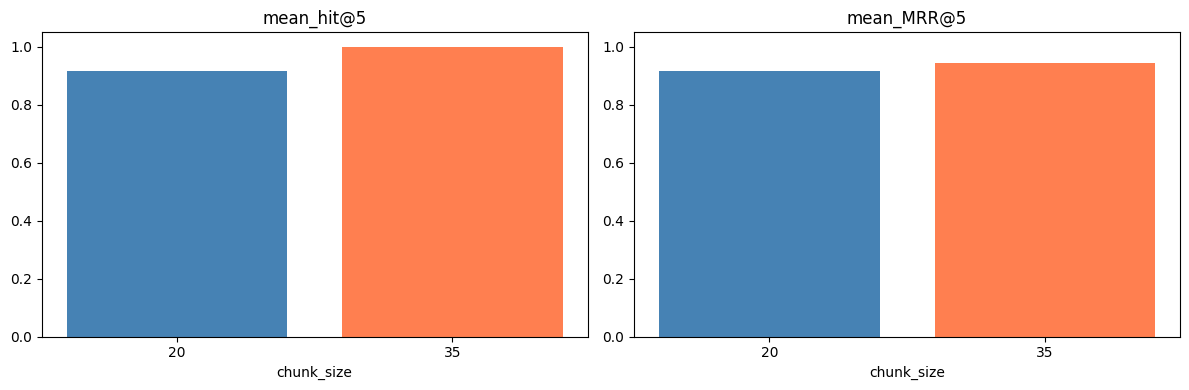

Вывод: chunk_size=25 (основной) — хороший баланс между детализацией и контекстом.


In [11]:
experiment_configs = [
    {"chunk_size": 20, "overlap": 5},
    {"chunk_size": 35, "overlap": 10},
]

experiment_results = []

for cfg in experiment_configs:
    exp_artifacts = build_retriever(
        documents,
        chunk_size=cfg["chunk_size"],
        overlap=cfg["overlap"],
        embedder_instance=embedder,
    )
    exp_eval = evaluate_benchmark(benchmark_queries, artifacts=exp_artifacts, top_k=TOP_K)
    experiment_results.append({
        "chunk_size": cfg["chunk_size"],
        "overlap": cfg["overlap"],
        "num_chunks": len(exp_artifacts.chunks_df),
        f"mean_hit@{TOP_K}": exp_eval[f"hit@{TOP_K}"].mean(),
        f"mean_recall@{TOP_K}": exp_eval[f"recall@{TOP_K}"].mean(),
        f"mean_MRR@{TOP_K}": exp_eval[f"MRR@{TOP_K}"].mean(),
    })

experiment_df = pd.DataFrame(experiment_results)
display(Markdown("### Сравнение chunk_size: 20 vs 35"))
display(experiment_df)

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
x_labels = [str(cfg["chunk_size"]) for cfg in experiment_configs]

axes[0].bar(x_labels, [r[f"mean_hit@{TOP_K}"] for r in experiment_results], color=["steelblue", "coral"])
axes[0].set_title(f"mean_hit@{TOP_K}")
axes[0].set_xlabel("chunk_size")
axes[0].set_ylim(0, 1.05)

axes[1].bar(x_labels, [r[f"mean_MRR@{TOP_K}"] for r in experiment_results], color=["steelblue", "coral"])
axes[1].set_title(f"mean_MRR@{TOP_K}")
axes[1].set_xlabel("chunk_size")
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig(os.path.join(ARTIFACTS_DIR, "retrieval_quality_plot.png"), dpi=100, bbox_inches="tight")
plt.show()
print("Вывод: chunk_size=25 (основной) — хороший баланс между детализацией и контекстом.")

## 7. Обновление базы знаний и переиндексация

In [12]:
new_documents = [
    {
        "doc_id": "doc_21",
        "title": "Аугментация данных",
        "text": (
            "Аугментация данных — техника увеличения обучающей выборки за счёт трансформаций исходных примеров. "
            "В компьютерном зрении применяют повороты, отражения, обрезку и изменение яркости. "
            "В NLP используют замену синонимов, случайное удаление слов и обратный перевод. "
            "Аугментация помогает модели лучше обобщаться и снижает переобучение."
        ),
    },
    {
        "doc_id": "doc_22",
        "title": "Ансамблевые методы: стекинг",
        "text": (
            "Стекинг (stacking) — ансамблевый метод, в котором предсказания нескольких базовых моделей "
            "подаются как признаки мета-модели. Мета-модель обучается комбинировать выходы базовых моделей. "
            "Стекинг часто улучшает качество по сравнению с простым усреднением или голосованием. "
            "Для корректного обучения мета-модели используют out-of-fold предсказания."
        ),
    },
    {
        "doc_id": "doc_23",
        "title": "Батч-нормализация",
        "text": (
            "Batch normalization нормализует активации внутри мини-батча, стабилизируя обучение. "
            "Она уменьшает зависимость от инициализации весов и позволяет использовать более высокий learning rate. "
            "BatchNorm располагается между линейным слоем и функцией активации. "
            "На инференсе используются фиксированные статистики (running mean и variance)."
        ),
    },
]

display(Markdown("### Новые документы для добавления"))
display(pd.DataFrame(new_documents)[["doc_id", "title"]])

# Запросы, ориентированные на новые документы
new_queries = [
    "Какие техники аугментации применяют в NLP?",
    "Как работает стекинг в ансамблевых методах?",
    "Зачем нужна батч-нормализация в нейросетях?",
]

display(Markdown("### Ответы СТАРОЙ базы на новые запросы (до обновления)"))
before_results = {}
for q in new_queries:
    display(Markdown(f"**Запрос:** {q}"))
    res = search_chunks(q, artifacts=artifacts, top_k=3)
    display(res[["rank", "score", "doc_id", "title", "chunk_text"]])
    before_results[q] = unique_doc_order(res)

### Новые документы для добавления

,doc_id,title
0,doc_21,Аугментация данных
1,doc_22,Ансамблевые методы: стекинг
2,doc_23,Батч-нормализация


### Ответы СТАРОЙ базы на новые запросы (до обновления)

**Запрос:** Какие техники аугментации применяют в NLP?

,rank,score,doc_id,title,chunk_text
0,1,0.4973,doc_15,Трансферное обучение,дообучают (fine-tune) последние слои или добав...
1,2,0.4743,doc_16,Обработка пропусков в данных,столбцов с пропусками. Более продвинутые метод...
2,3,0.4567,doc_17,Снижение размерности (PCA),и удаления шума. Количество компонент выбирают...


**Запрос:** Как работает стекинг в ансамблевых методах?

,rank,score,doc_id,title,chunk_text
0,1,0.6750,doc_03,Деревья решений,pruning. На практике их чаще используют как ба...
1,2,0.5032,doc_14,Механизм внимания (Attention),использует несколько параллельных головок для ...
2,3,0.4676,doc_05,Градиентный бустинг,Градиентный бустинг строит ансамбль последоват...


**Запрос:** Зачем нужна батч-нормализация в нейросетях?

,rank,score,doc_id,title,chunk_text
0,1,0.6411,doc_11,Нейронные сети: основы,"Нейронная сеть состоит из слоёв нейронов, связ..."
1,2,0.4810,doc_11,Нейронные сети: основы,"(ReLU, sigmoid, tanh). Обучение происходит чер..."
2,3,0.4615,doc_08,Нормализация и стандартизация данных,Перед обучением модели числовые признаки часто...


In [13]:
# Обновлённая база знаний
updated_documents = documents + new_documents
print(f"Было документов: {len(documents)}, стало: {len(updated_documents)}")

updated_artifacts = build_retriever(
    updated_documents,
    chunk_size=CHUNK_SIZE,
    overlap=OVERLAP,
    embedder_instance=embedder,
)
print(f"Чанков после обновления: {len(updated_artifacts.chunks_df)}")

display(Markdown("### Ответы НОВОЙ базы на те же запросы (после обновления)"))
after_results = {}
for q in new_queries:
    display(Markdown(f"**Запрос:** {q}"))
    res = search_chunks(q, artifacts=updated_artifacts, top_k=3)
    display(res[["rank", "score", "doc_id", "title", "chunk_text"]])
    after_results[q] = unique_doc_order(res)

Было документов: 20, стало: 23
Чанков после обновления: 55


### Ответы НОВОЙ базы на те же запросы (после обновления)

**Запрос:** Какие техники аугментации применяют в NLP?

,rank,score,doc_id,title,chunk_text
0,1,0.5156,doc_21,Аугментация данных,обрезку и изменение яркости. В NLP используют ...
1,2,0.4973,doc_15,Трансферное обучение,дообучают (fine-tune) последние слои или добав...
2,3,0.4743,doc_16,Обработка пропусков в данных,столбцов с пропусками. Более продвинутые метод...


**Запрос:** Как работает стекинг в ансамблевых методах?

,rank,score,doc_id,title,chunk_text
0,1,0.6750,doc_03,Деревья решений,pruning. На практике их чаще используют как ба...
1,2,0.5759,doc_22,Ансамблевые методы: стекинг,"Стекинг (stacking) — ансамблевый метод, в кото..."
2,3,0.5032,doc_14,Механизм внимания (Attention),использует несколько параллельных головок для ...


**Запрос:** Зачем нужна батч-нормализация в нейросетях?

,rank,score,doc_id,title,chunk_text
0,1,0.6411,doc_11,Нейронные сети: основы,"Нейронная сеть состоит из слоёв нейронов, связ..."
1,2,0.4810,doc_11,Нейронные сети: основы,"(ReLU, sigmoid, tanh). Обучение происходит чер..."
2,3,0.4735,doc_23,Батч-нормализация,Batch normalization нормализует активации внут...


In [14]:
# Сравнение до и после + сохранение retrieval_before_after_update.csv
ba_rows = []
for q in new_queries:
    before_sources = before_results[q]
    after_sources = after_results[q]
    ba_rows.append({
        "query": q,
        "before_retrieved_sources": ", ".join(before_sources),
        "after_retrieved_sources": ", ".join(after_sources),
        "changed": before_sources != after_sources,
    })

# Добавляем пару запросов из основного benchmark для полноты
for bq in benchmark_queries[:3]:
    q = bq["query"]
    before_res = search_chunks(q, artifacts=artifacts, top_k=3)
    after_res = search_chunks(q, artifacts=updated_artifacts, top_k=3)
    b_src = unique_doc_order(before_res)
    a_src = unique_doc_order(after_res)
    ba_rows.append({
        "query": q,
        "before_retrieved_sources": ", ".join(b_src),
        "after_retrieved_sources": ", ".join(a_src),
        "changed": b_src != a_src,
    })

ba_df = pd.DataFrame(ba_rows)
ba_path = os.path.join(ARTIFACTS_DIR, "retrieval_before_after_update.csv")
ba_df.to_csv(ba_path, index=False)
print(f"Сохранено: {ba_path}")
display(ba_df)

Сохранено: c:\Users\Maxim\Downloads\ai-student-maxim-main (4)\ai-student-maxim-main\homeworks\HW14\artifacts\retrieval_before_after_update.csv


,query,before_retrieved_sources,after_retrieved_sources,changed
0,Какие техники аугментации применяют в NLP?,"doc_15, doc_16, doc_17","doc_21, doc_15, doc_16",True
1,Как работает стекинг в ансамблевых методах?,"doc_03, doc_14, doc_05","doc_03, doc_22, doc_14",True
2,Зачем нужна батч-нормализация в нейросетях?,"doc_11, doc_08","doc_11, doc_23",True
3,Как обучается линейная регрессия?,"doc_01, doc_02","doc_01, doc_23",True
4,Что такое сигмоидная функция в логистической р...,doc_02,doc_02,False
5,По какому критерию дерево решений разбивает да...,"doc_03, doc_05, doc_04","doc_03, doc_05, doc_04",False


## 8. Mini-RAG

In [15]:
def split_into_sentences(text: str) -> List[str]:
    parts = re.split(r"(?<=[.!?])\s+", text.strip())
    return [p.strip() for p in parts if p.strip()]


def build_context_from_retrieval(
    query: str,
    artifacts: RetrievalArtifacts,
    top_k: int = 3,
) -> Tuple[str, pd.DataFrame]:
    retrieved = search_chunks(query, artifacts=artifacts, top_k=top_k)
    context_blocks = []
    for _, row in retrieved.iterrows():
        block = (
            f"[Источник: {row['doc_id']} | {row['title']} | score={row['score']:.4f}]\n"
            f"{row['chunk_text']}"
        )
        context_blocks.append(block)
    context = "\n\n".join(context_blocks)
    return context, retrieved


def generate_answer_from_context(query: str, context: str, max_sentences: int = 3) -> str:
    raw_lines = [line.strip() for line in context.splitlines() if line.strip()]
    content_lines = [line for line in raw_lines if not line.startswith("[Источник:")]

    sentence_pool = []
    for line in content_lines:
        sentence_pool.extend(split_into_sentences(line))
    sentence_pool = [s for s in sentence_pool if len(s.split()) >= 4]

    if not sentence_pool:
        return "Недостаточно контекста для построения ответа."

    vectorizer = TfidfVectorizer(ngram_range=(1, 2))
    matrix = vectorizer.fit_transform([query] + sentence_pool).toarray().astype(np.float32)

    query_vec = matrix[0]
    sentence_vecs = matrix[1:]
    query_norm = np.linalg.norm(query_vec) + 1e-12
    sent_norms = np.linalg.norm(sentence_vecs, axis=1) + 1e-12
    scores = (sentence_vecs @ query_vec) / (sent_norms * query_norm)

    ranked_idx = np.argsort(-scores)
    selected = []
    used = set()
    for idx in ranked_idx:
        s = sentence_pool[idx]
        norm = s.lower().strip()
        if scores[idx] <= 0 or norm in used:
            continue
        used.add(norm)
        selected.append(s)
        if len(selected) >= max_sentences:
            break

    if not selected:
        return "В найденном контексте нет достаточно релевантного фрагмента."
    return " ".join(selected)


def mini_rag_answer(
    query: str,
    artifacts: RetrievalArtifacts,
    top_k: int = 3,
    max_sentences: int = 3,
) -> Dict[str, object]:
    context, retrieved = build_context_from_retrieval(query, artifacts=artifacts, top_k=top_k)
    answer = generate_answer_from_context(query, context=context, max_sentences=max_sentences)
    sources = retrieved[["doc_id", "title", "score"]].to_dict("records")
    return {
        "query": query,
        "answer": answer,
        "context": context,
        "sources": sources,
        "retrieved_df": retrieved,
    }


print("Mini-RAG конвейер готов.")

Mini-RAG конвейер готов.


In [16]:
# Демонстрация mini-RAG на обновлённой базе
rag_queries = [
    "Как работает линейная регрессия?",
    "Чем precision отличается от recall?",
    "Зачем нужна регуляризация модели?",
    "Что такое свёрточные нейронные сети?",
    "Как работает механизм внимания?",
    "Какие техники аугментации применяют в NLP?",
    "Как работает стекинг в ансамблевых методах?",
    "Зачем нужна батч-нормализация?",
]

rag_examples_rows = []

for q in rag_queries:
    result = mini_rag_answer(q, artifacts=updated_artifacts, top_k=3)
    display(Markdown(f"### Вопрос: {q}"))
    display(Markdown(f"**Ответ:** {result['answer']}"))
    display(Markdown(f"**Источники:** {', '.join(s['doc_id'] + ' (' + s['title'] + ')' for s in result['sources'])}"))
    print()

    rag_examples_rows.append({
        "question": q,
        "answer": result["answer"],
        "retrieved_sources": ", ".join(s["doc_id"] for s in result["sources"]),
    })

# Сохранение rag_examples.csv
rag_examples_df = pd.DataFrame(rag_examples_rows)
rag_path = os.path.join(ARTIFACTS_DIR, "rag_examples.csv")
rag_examples_df.to_csv(rag_path, index=False)
print(f"\nСохранено: {rag_path}")
display(rag_examples_df)

### Вопрос: Как работает линейная регрессия?

**Ответ:** Линейная регрессия — один из простейших методов машинного обучения. Она моделирует зависимость целевой переменной от признаков как линейную комбинацию весов. Логистическая регрессия — это линейный классификатор, который предсказывает вероятность принадлежности к классу.

**Источники:** doc_01 (Линейная регрессия), doc_01 (Линейная регрессия), doc_02 (Логистическая регрессия)

### Вопрос: Чем precision отличается от recall?

**Ответ:** F1 — гармоническое среднее precision и recall. Основные метрики классификации: accuracy, precision, recall и F1-score. Precision — доля действительно положительных

...

### Вопрос: Зачем нужна батч-нормализация?

**Ответ:** Min-max нормализация приводит значения к диапазону [0, 1].

**Источники:** doc_08 (Нормализация и стандартизация данных), doc_23 (Батч-нормализация), doc_10 (Регуляризация)



Сохранено: c:\Users\Maxim\Downloads\ai-student-maxim-main (4)\ai-student-maxim-main\homeworks\HW14\artifacts\rag_examples.csv


,question,answer,retrieved_sources
0,Как работает линейная регрессия?,Линейная регрессия — один из простейших методо...,"doc_01, doc_01, doc_02"
1,Чем precision отличается от recall?,F1 — гармоническое среднее precision и recall....,"doc_07, doc_07, doc_07"
2,Зачем нужна регуляризация модели?,Регуляризация помогает бороться с переобучение...,"doc_10, doc_10, doc_08"
3,Что такое свёрточные нейронные сети?,"Это особенно важно для алгоритмов, чувствитель...","doc_11, doc_08, doc_16"
4,Как работает механизм внимания?,Механизм внимания позволяет модели сосредоточи...,"doc_14, doc_14, doc_11"
5,Какие техники аугментации применяют в NLP?,В NLP трансферное обучение стало стандартом бл...,"doc_21, doc_15, doc_16"
6,Как работает стекинг в ансамблевых методах?,"Стекинг (stacking) — ансамблевый метод, в кото...","doc_03, doc_22, doc_14"
7,Зачем нужна батч-нормализация?,Min-max нормализация приводит значения к диапа...,"doc_08, doc_23, doc_10"


## 9. Краткий анализ ошибок

In [17]:
# Проблемные / пограничные запросы для mini-RAG
error_queries = [
    {
        "query": "Как бороться с утечкой данных при обучении?",
        "comment": "В базе нет документа про data leakage. Ожидаем нерелевантный ответ.",
    },
    {
        "query": "Что лучше: Random Forest или градиентный бустинг?",
        "comment": "Запрос сравнительный, но мы ищем по одному top-k. Retrieval может смешать контекст.",
    },
    {
        "query": "Как выбирать гиперпараметры для нейронной сети?",
        "comment": "Релевантны doc_18 (подбор гиперпараметров) и doc_11 (нейросети). Контекст может быть размытым.",
    },
    {
        "query": "Расскажи про word2vec",
        "comment": "В базе нет прямого документа про word2vec, только упоминание embeddings в doc_09.",
    },
]

for item in error_queries:
    q = item["query"]
    result = mini_rag_answer(q, artifacts=updated_artifacts, top_k=3)

    display(Markdown(f"### Запрос: {q}"))
    display(Markdown(f"*Ожидание:* {item['comment']}"))
    display(Markdown(f"**Ответ mini-RAG:** {result['answer']}"))
    display(result["retrieved_df"][["rank", "score", "doc_id", "title"]])
    print()

display(Markdown(
    "### Выводы по ошибкам\n"
    "1. **Неполнота базы знаний** — если вопрос выходит за пределы базы, retrieval возвращает тематически \n"
    "   близкие, но не по-настоящему полезные фрагменты. Mini-RAG в таком случае компилирует ответ \n"
    "   из нерелевантных предложений.\n"
    "2. **Сравнительные запросы** — retrieval по одному вектору плохо справляется с вопросами, требующими \n"
    "   контекст сразу из нескольких документов. Увеличение top_k может помочь.\n"
    "3. **Размытый контекст** — когда вопрос затрагивает две темы, top-3 может включить чанки \n"
    "   из обоих документов, но не наиболее релевантные из каждого.\n"
    "4. **Узкие термины** — конкретные названия (word2vec), отсутствующие в базе, дают низкие скоры \n"
    "   и случайный подбор контекста."
))

### Запрос: Как бороться с утечкой данных при обучении?

*Ожидание:* В базе нет документа про data leakage. Ожидаем нерелевантный ответ.

**Ответ mini-RAG:** Это особенно эффективно при малом объёме данных в целевой задаче. Трансферное обучение использует модель, предобученную на большом датасете, как начальную точку для новой задачи. Аугментация данных — техника увеличения обучающей выборки за счёт трансформаций исходных примеров.

,rank,score,doc_id,title
0,1,0.6553,doc_15,Трансферное обучение
1,2,0.6177,doc_21,Аугментация данных
2,3,0.6042,doc_15,Трансферное обучение


### Запрос: Что лучше: Random Forest или градиентный бустинг?

...

### Запрос: Расскажи про word2vec

*Ожидание:* В базе нет прямого документа про word2vec, только упоминание embeddings в doc_09.

**Ответ mini-RAG:** В найденном контексте нет достаточно релевантного фрагмента.

,rank,score,doc_id,title
0,1,0.3608,doc_21,Аугментация данных
1,2,0.3535,doc_09,Feature engineering
2,3,0.3116,doc_13,Рекуррентные нейронные сети (RNN)


### Выводы по ошибкам
1. **Неполнота базы знаний** — если вопрос выходит за пределы базы, retrieval возвращает тематически 
   близкие, но не по-настоящему полезные фрагменты. Mini-RAG в таком случае компилирует ответ 
   из нерелевантных предложений.
2. **Сравнительные запросы** — retrieval по одному вектору плохо справляется с вопросами, требующими 
   контекст сразу из нескольких документов. Увеличение top_k может помочь.
3. **Размытый контекст** — когда вопрос затрагивает две темы, top-3 может включить чанки 
   из обоих документов, но не наиболее релевантные из каждого.
4. **Узкие термины** — конкретные названия (word2vec), отсутствующие в базе, дают низкие скоры 
   и случайный подбор контекста.

In [18]:
print("=== HW14 завершена ===")
print(f"Артефакты в: {ARTIFACTS_DIR}")
for f in os.listdir(ARTIFACTS_DIR):
    print(f"  {f}")

=== HW14 завершена ===
Артефакты в: c:\Users\Maxim\Downloads\ai-student-maxim-main (4)\ai-student-maxim-main\homeworks\HW14\artifacts
  rag_examples.csv
  retrieval_before_after_update.csv
  retrieval_eval.csv
  retrieval_quality_plot.png
